Random_state:  75
              precision    recall  f1-score   support

    Na_ultra       0.50      0.40      0.44         5
         Not       0.79      0.85      0.81        13

    accuracy                           0.72        18
   macro avg       0.64      0.62      0.63        18
weighted avg       0.71      0.72      0.71        18

Accuracy: 72.22222222222221 %


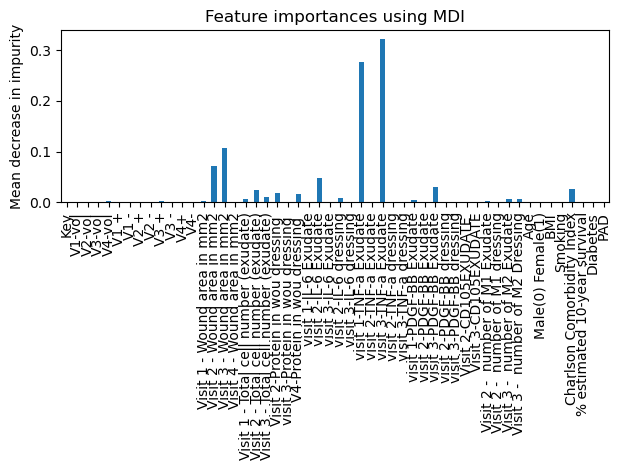

[[ 1.3411826e-01  8.6588174e-01]
 [ 6.3341689e-01  3.6658311e-01]
 [ 2.1398038e-01  7.8601962e-01]
 [ 1.2434751e-01  8.7565249e-01]
 [ 6.8246305e-01  3.1753695e-01]
 [ 4.9055052e-01  5.0944948e-01]
 [ 9.8009360e-01  1.9906402e-02]
 [ 4.3294132e-02  9.5670587e-01]
 [ 7.5332308e-01  2.4667692e-01]
 [-1.0598183e-02  1.0105982e+00]
 [-7.8201294e-05  1.0000782e+00]
 [-5.1321983e-03  1.0051322e+00]
 [ 5.9191585e-03  9.9408084e-01]
 [ 4.5978606e-02  9.5402139e-01]
 [-8.5115433e-05  1.0000851e+00]
 [-6.5755844e-03  1.0065756e+00]
 [-1.0802746e-03  1.0010803e+00]
 [ 3.2645702e-02  9.6735430e-01]]


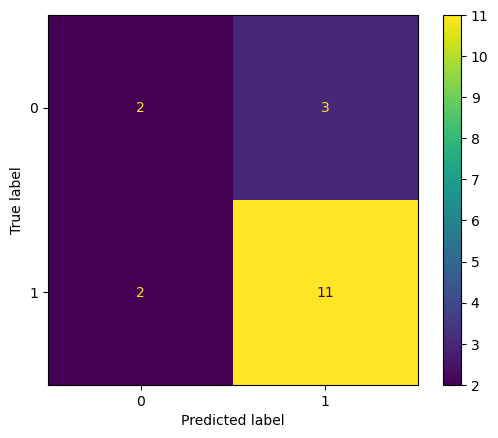

<Figure size 40000x12000 with 0 Axes>

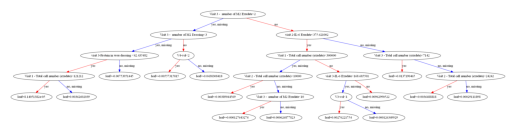

              precision    recall  f1-score   support

    Na_ultra       1.00      1.00      1.00        12
         Not       1.00      1.00      1.00        33

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

--------------------------------------------------------------------------------------------------


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model
from xgboost import *

W_tree=6

Treatment=pd.read_csv("../AD report/NA pathway train.csv")
Treatment_test=pd.read_csv("../AD report/NA pathway test.csv")


X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]


#y_train = to_categorical(y_train)
#y_test = to_categorical(y_test)



R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=11




           
    
clf=XGBClassifier(booster="dart",
                  normalize_type="forest",
                  tree_method="hist",
                    objective="reg:pseudohubererror",
                  eta=0.5,
                 # max_depth=4,
                  #subsample=0.6,
                 # colsample_bytree=0.8,
                 # colsample_bylevel=0.9,
                 colsample_bynode=0.7,
                  #reg_lambda=0.6,
                  #reg_alpha=0.7,
                  #rate_drop=1,
                  skip_drop=0.6,
                  #one_drop=1,
                    random_state=R_state,
                  max_bin=2056,
                #num_parallel_tree=5,
                  grow_policy="lossguide",
                  sample_type="weighted",
                
                  
                  
                  
    )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test, iteration_range=(0, 100))
y_pred = (y_pred > 0.5) 


class_names=["Na_ultra","Not"]

print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names
importances = clf.feature_importances_

forest_importances = pd.Series(importances, index=names)
#forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()

y_pred = clf.predict(X_train)
y_pred = (y_pred > 0.5) 
print(classification_report(y_train,y_pred,output_dict=False,target_names=class_names))

print("--------------------------------------------------------------------------------------------------")

target = 'key'



from supertree import SuperTree
st = SuperTree(
    clf, 
    X_train, 
    y_train, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)

